In [160]:
import numpy as np
import pandas as pd
from scipy.signal import welch
from sklearn.preprocessing import StandardScaler
import os, json

In [161]:
# PARAMETERS (change if needed)
FILE = "./data/badge_positions_tracked_01 - Sheet3.csv"   # path to your file
SHEET = None                               # or "Sheet1"
FS = 25.0                                  # sampling frequency (Hz)
WINDOW_SEC = 2.0                           # window length (seconds)
WINDOW_SIZE = int(WINDOW_SEC * FS)         # samples per window (default 50)
OVERLAP = 0.5                              # 0..1 (50% overlap)
STRIDE = int(WINDOW_SIZE * (1 - OVERLAP)) or 1
LABEL_THRESH = 0.7                         # fraction of state==1 to label window as working
OUT_DIR = "dataset_artifacts"
os.makedirs(OUT_DIR, exist_ok=True)

print("window_size:", WINDOW_SIZE, "stride:", STRIDE)

window_size: 50 stride: 25


In [162]:
# Cell 1 — load data
ext = FILE.split('.')[-1].lower()
if ext in ("xls","xlsx"):
    df = pd.read_excel(FILE, sheet_name=SHEET)
elif ext == "csv":
    df = pd.read_csv(FILE)
else:
    raise ValueError("Unsupported file extension: " + ext)

# check columns
expected = {'second','hand_2_x','hand_2_y','state'}
if not expected.issubset(set(df.columns)):
    raise ValueError(f"Input file must contain columns: {expected}. Found: {df.columns}")

df = df.reset_index(drop=True)
print("Loaded rows:", len(df))
display(df.head())


Loaded rows: 8520


,second,hand_2_x,hand_2_y,state
0,0.04,414,383,1
1,0.08,415,383,1
2,0.12,415,383,1
3,0.16,414,382,1
4,0.20,414,382,1


In [163]:
# Cell 2 — basic diagnostics (optional but useful)
print("Time range:", df['second'].min(), "to", df['second'].max())
print("States distribution:\n", df['state'].value_counts(normalize=True))
# quick plot (uncomment if running in notebook)
# import matplotlib.pyplot as plt
# plt.plot(df['second'], df['hand_2_x']); plt.title('hand_2_x'); plt.show()

Time range: 0.04 to 340.8
States distribution:
 state
0    0.719014
1    0.280986
Name: proportion, dtype: float64


In [164]:
# Cell 3 — sliding windows + label assignment
def make_windows(df, window_size, stride, cols_xy=('hand_2_x','hand_2_y'), label_thresh=0.7):
    xs = df[list(cols_xy)].values
    states = df['state'].values
    n = len(df)
    X_seq = []
    y = []
    index_pairs = []
    for start in range(0, n - window_size + 1, stride):
        end = start + window_size
        win = xs[start:end]            # shape (window_size, 2)
        win_states = states[start:end]
        frac = np.mean(win_states == 1)
        label = 1 if frac >= label_thresh else 0
        X_seq.append(win)
        y.append(label)
        index_pairs.append((start, end))
    X_seq = np.stack(X_seq)   # (n_windows, window_size, 2)
    y = np.array(y)
    return X_seq, y, index_pairs

X_seq, y, idx_pairs = make_windows(df, WINDOW_SIZE, STRIDE, label_thresh=LABEL_THRESH)
print("Windows created:", X_seq.shape[0])
print("Label counts:", np.bincount(y))


Windows created: 339
Label counts: [246  93]


In [165]:
# Cell 4 — feature extraction per window
# We'll compute: mean_x, mean_y, std_x, std_y, min_x, max_x, min_y, max_y,
# speed_mean, speed_std, accel_mean, accel_std, dominant_freq_of_speed, speed_energy
from scipy.signal import welch

def summary_features(window, fs=FS):
    x = window[:,0].astype(float)
    y = window[:,1].astype(float)
    dt = 1.0 / fs
    vx = np.gradient(x, dt)
    vy = np.gradient(y, dt)
    speed = np.sqrt(vx**2 + vy**2)
    ax = np.gradient(vx, dt)
    ay = np.gradient(vy, dt)
    feats = []
    # position stats
    feats += [np.mean(x), np.std(x), np.min(x), np.max(x)]
    feats += [np.mean(y), np.std(y), np.min(y), np.max(y)]
    # speed/accel stats
    feats += [np.mean(speed), np.std(speed), np.mean(ax), np.std(ax)]
    # frequency for speed
    f, Pxx = welch(speed, fs=fs, nperseg=min(128, len(speed)))
    if len(Pxx)>0:
        dom_idx = np.argmax(Pxx)
        feats += [f[dom_idx], np.sum(Pxx)]
    else:
        feats += [0.0, 0.0]
    return np.array(feats)

# compute for all windows
X_feat = np.stack([summary_features(X_seq[i]) for i in range(len(X_seq))])
print("Feature vector shape:", X_feat.shape)
# Optional: feature names
feat_names = [
    "mean_x","std_x","min_x","max_x",
    "mean_y","std_y","min_y","max_y",
    "speed_mean","speed_std","acc_mean","acc_std",
    "dom_freq","speed_energy"
]
print("Features:", feat_names)


Feature vector shape: (339, 14)
Features: ['mean_x', 'std_x', 'min_x', 'max_x', 'mean_y', 'std_y', 'min_y', 'max_y', 'speed_mean', 'speed_std', 'acc_mean', 'acc_std', 'dom_freq', 'speed_energy']


In [166]:
# Cell 5 — inspect a few windows & features (human-readable)
n_show = 3
for i in range(n_show):
    s,e = idx_pairs[i]
    print(f"Window {i} rows {s}..{e-1}, label={y[i]}")
    print("first 5 frames:\n", X_seq[i][:5])
    print("feature vector:\n", np.round(X_feat[i],4))
    print("-"*60)


Window 0 rows 0..49, label=1
first 5 frames:
 [[414 383]
 [415 383]
 [415 383]
 [414 382]
 [414 382]]
feature vector:
 [ 4.3740000e+02  1.3003100e+01  4.1400000e+02  4.5000000e+02
  3.9276000e+02  7.3744000e+00  3.8100000e+02  4.0100000e+02
  4.2129500e+01  4.0467300e+01 -8.1250000e+01  2.9355050e+02
  5.0000000e-01  2.5311156e+03]
------------------------------------------------------------
Window 1 rows 25..74, label=1
first 5 frames:
 [[448 401]
 [449 401]
 [449 401]
 [450 401]
 [449 401]]
feature vector:
 [4.2946000e+02 1.7164200e+01 4.0700000e+02 4.5000000e+02 3.8862000e+02
 8.8677000e+00 3.7800000e+02 4.0100000e+02 4.5719500e+01 4.2246100e+01
 1.5625000e+01 2.9851520e+02 1.0000000e+00 3.9947617e+03]
------------------------------------------------------------
Window 2 rows 50..99, label=1
first 5 frames:
 [[417 381]
 [413 380]
 [410 380]
 [408 380]
 [407 380]]
feature vector:
 [4.2494000e+02 1.6186900e+01 4.0600000e+02 4.4700000e+02 3.8646000e+02
 7.7594000e+00 3.7800000e+02 3.99

In [167]:
# Cell 6 — scale features and sequences, save artifacts
# Scale features with StandardScaler; scale sequence channels jointly (fit on flattened timepoints)
seq_scaler = StandardScaler().fit(X_seq.reshape(-1, X_seq.shape[-1]))
X_seq_scaled = seq_scaler.transform(X_seq.reshape(-1, X_seq.shape[-1])).reshape(X_seq.shape)

feat_scaler = StandardScaler().fit(X_feat)
X_feat_scaled = feat_scaler.transform(X_feat)

# Save arrays and scalers
np.save(os.path.join(OUT_DIR, 'X_seq.npy'), X_seq)                 # raw sequences
np.save(os.path.join(OUT_DIR, 'X_seq_scaled.npy'), X_seq_scaled)   # scaled sequences
np.save(os.path.join(OUT_DIR, 'X_feat.npy'), X_feat)               # raw features
np.save(os.path.join(OUT_DIR, 'X_feat_scaled.npy'), X_feat_scaled) # scaled features
np.save(os.path.join(OUT_DIR, 'y.npy'), y)
# save index pairs to map windows back to original rows
with open(os.path.join(OUT_DIR, 'index_pairs.json'), 'w') as f:
    json.dump(idx_pairs, f)

# save scalers with joblib if you want (pip install joblib)
import joblib
joblib.dump(seq_scaler, os.path.join(OUT_DIR, 'seq_scaler.joblib'))
joblib.dump(feat_scaler, os.path.join(OUT_DIR, 'feat_scaler.joblib'))

print("Saved artifacts to", OUT_DIR)
print("X_seq.npy shape:", X_seq.shape)
print("X_feat.npy shape:", X_feat.shape)
print("y.npy shape:", y.shape)


Saved artifacts to dataset_artifacts
X_seq.npy shape: (339, 50, 2)
X_feat.npy shape: (339, 14)
y.npy shape: (339,)


In [168]:
# Cell 7 — also save a human-readable CSV with one row per window (useful for quick inspection)
df_windows = pd.DataFrame(X_feat, columns=feat_names)
df_windows['label'] = y
df_windows['start_row'] = [s for s,e in idx_pairs]
df_windows['end_row'] = [e for s,e in idx_pairs]
df_windows.to_csv(os.path.join(OUT_DIR, 'windows_features_labels.csv'), index=False)
print("Saved windows_features_labels.csv")
display(df_windows.head())


Saved windows_features_labels.csv


,mean_x,std_x,min_x,max_x,mean_y,std_y,min_y,max_y,speed_mean,speed_std,acc_mean,acc_std,dom_freq,speed_energy,label,start_row,end_row
0,437.40,13.003077,414.0,450.0,392.76,7.374442,381.0,401.0,42.129538,40.467295,-81.250,293.550464,0.5,2531.115622,1,0,50
1,429.46,17.164160,407.0,450.0,388.62,8.867672,378.0,401.0,45.719469,42.246067,15.625,298.515206,1.0,3994.761738,1,25,75
2,424.94,16.186921,406.0,447.0,386.46,7.759407,378.0,399.0,54.301895,47.414969,59.375,419.134618,1.0,3798.654462,1,50,100
3,430.42,16.193937,406.0,447.0,389.78,8.227491,378.0,399.0,51.738088,48.907261,-9.375,417.406895,1.5,5505.112026,1,75,125
4,422.08,15.414071,405.0,445.0,385.74,7.992021,377.0,399.0,53.691688,45.017526,25.000,368.908864,1.5,4779.484420,1,100,150


In [169]:
from sklearn.model_selection import train_test_split

# 80% training, 20% testing
X_seq_train, X_seq_test, X_feat_train, X_feat_test, y_train, y_test = train_test_split(
    X_seq, X_feat, y, test_size=0.2, random_state=42, shuffle=True
)

print("Train sequences:", X_seq_train.shape)
print("Test sequences:", X_seq_test.shape)
print("Train features:", X_feat_train.shape)
print("Test features:", X_feat_test.shape)
print("Train labels:", y_train.shape)
print("Test labels:", y_test.shape)


Train sequences: (271, 50, 2)
Test sequences: (68, 50, 2)
Train features: (271, 14)
Test features: (68, 14)
Train labels: (271,)
Test labels: (68,)


In [170]:
import tensorflow as tf
from tensorflow.keras import layers, models

# input shape: (timesteps=WINDOW_SIZE, features=2)
timesteps = X_seq_train.shape[1]
features = X_seq_train.shape[2]

model = models.Sequential([
    layers.Input(shape=(timesteps, features)),
    
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.3),
    
    layers.LSTM(32),
    layers.Dropout(0.2),
    
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # binary classification
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                  │ (None, 50, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,113 (117.63 KB)

 Trainable params: 30,113 (117.63 KB)

 Non-trainable params: 0 (0.00 B)

In [171]:
history = model.fit(
    X_seq_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    shuffle=True
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.5787 - loss: 0.6773 - val_accuracy: 0.7273 - val_loss: 0.6250
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7315 - loss: 0.5956 - val_accuracy: 0.7273 - val_loss: 0.5569
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7222 - loss: 0.5315 - val_accuracy: 0.7273 - val_loss: 0.4875
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7963 - loss: 0.4433 - val_accuracy: 0.9091 - val_loss: 0.3928
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8796 - loss: 0.3581 - val_accuracy: 0.9091 - val_loss: 0.3165
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8981 - loss: 0.2890 - val_accuracy: 0.9091 - val_loss: 0.2446
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9167 - loss: 0.2294 - val_accuracy: 0.9273 - val_loss: 0.2341
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9259 - loss: 0.2052 - val_accuracy: 0.9091 - val_loss: 0.1929


In [172]:
loss, acc = model.evaluate(X_seq_test, y_test)
print("Test accuracy:", acc)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8971 - loss: 0.2483
Test accuracy: 0.8970588445663452


In [173]:
y_pred_prob = model.predict(X_seq_test)
y_pred = (y_pred_prob > 0.5).astype(int)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


In [174]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.86      0.92        50
           1       0.72      1.00      0.84        18

    accuracy                           0.90        68
   macro avg       0.86      0.93      0.88        68
weighted avg       0.93      0.90      0.90        68

[[43  7]
 [ 0 18]]


In [175]:
import matplotlib.pyplot as plt
import numpy as np

# create sliding windows from the full sequence
def create_test_windows(df, window_size, stride, scaler):
    xs = df[['hand_2_x','hand_2_y']].values
    X_windows = []
    indices = []
    for start in range(0, len(xs)-window_size+1, stride):
        w = xs[start:start+window_size]
        w_scaled = scaler.transform(w)
        X_windows.append(w_scaled)
        indices.append((start, start+window_size))
    return np.stack(X_windows), indices

X_test_windows, idx_pairs = create_test_windows(df, WINDOW_SIZE, STRIDE, seq_scaler)


In [178]:
y_prob = model.predict(X_test_windows)
y_class = (y_prob > 0.5).astype(int)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


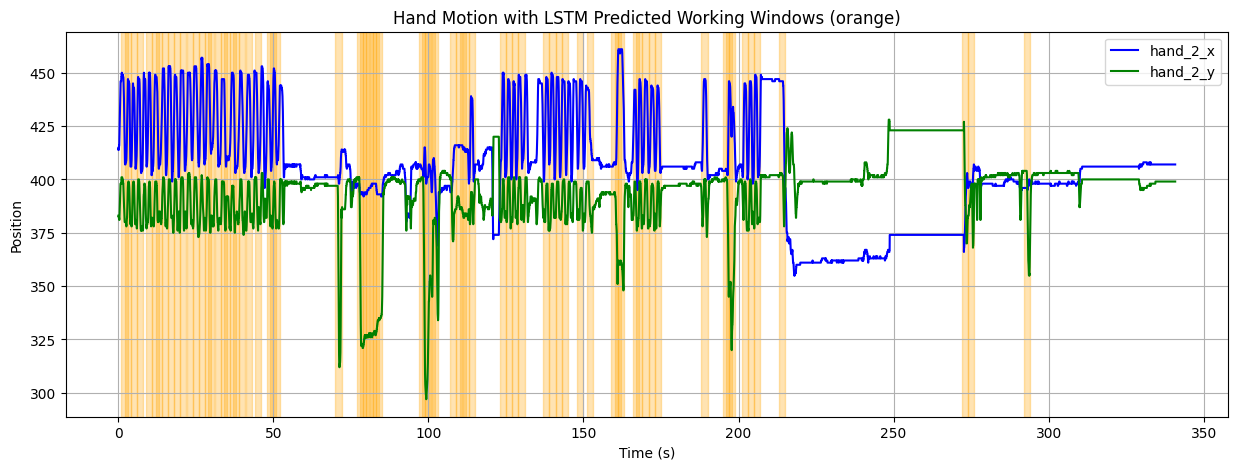

In [179]:
plt.figure(figsize=(15,5))
time = df['second'].values
hand_x = df['hand_2_x'].values
hand_y = df['hand_2_y'].values

plt.plot(time, hand_x, label='hand_2_x', color='blue')
plt.plot(time, hand_y, label='hand_2_y', color='green')

# overlay predicted working/not working
for i, (start, end) in enumerate(idx_pairs):
    if y_class[i][0] == 1:
        plt.axvspan(time[start], time[end-1], color='orange', alpha=0.3)

plt.xlabel("Time (s)")
plt.ylabel("Position")
plt.title("Hand Motion with LSTM Predicted Working Windows (orange)")
plt.legend()
plt.grid(True)
plt.show()